# CSE 475 - Assignment 01
## Group Information
| Field | Details |
|-------------------------|-------------------------------------|
| **Group ID** | Group 01 |
| **Student 1 Name** | Ahsanur Parul |
| **Student 1 ID** | 2022-3-60-190 |
| **Student 2 Name** | Tasnim Zaman |
| **Student 2 ID** | 2023-1-60-058  |
| **Student 3 Name** | Jannatul Ferdous Jerin |
| **Student 3 ID** | 2023-1-60-099  |
| **Student 4 Name** | Nabila Ibnat |
| **Student 4 ID** | 2023-1-60-136 |
| **Notebook Type** | CNN Models  |
| **Dataset Source Name** | BrinjalFruitX: A Field-Collected Image Dataset for Machine Learning and Deep Learning-Based Disease Identification in Brinjal Fruits |
| **Dataset Source Link** | https://data.mendeley.com/datasets/ngc58fsxgd/1 |
| **Kaggle Dataset Path** | /kaggle/input/datasets/ahsanurparul/brinjal-460x460 |
| **Submission Date** | 31 March 2026

# [*] Global Configuration 

In [1]:
# =========================================================
# GLOBAL CONFIGURATION
# =========================================================

class CFG:

    DATA_PATH = "/kaggle/input/brinjalfruitx"
    OUTPUT_DIR = "/kaggle/working"

    IMG_SIZE = 460

    BATCH_SIZE = 16
    EPOCHS = 30   

    LR = 3e-4
    WEIGHT_DECAY = 1e-4

    NUM_WORKERS = 2

    TRAIN_SPLIT = 0.7
    VAL_SPLIT = 0.15
    TEST_SPLIT = 0.15

    SEED = 42
    EARLY_STOP_PAT = 10
    
# ── GradCAM ────────────────────────────────────────────────────────
GRADCAM_SAMPLES_PER_CLASS = 2   # Images to visualize per class

# ── Robustness ─────────────────────────────────────────────────────
NOISE_LEVELS = [0.05, 0.15]   # Gaussian noise σ values to test
BLUR_KERNELS = [3, 9]         # Blur kernel sizes to test

IMAGENET_MEAN = [0.485,0.456,0.406]
IMAGENET_STD = [0.229,0.224,0.225]
# ── Display ────────────────────────────────────────────────────────
COLORS      = ['#E74C3C', '#F39C12', '#8E44AD', '#27AE60']
FIGDPI      = 120


# [+] Setup & Imports

In [2]:
!python --version

Python 3.12.12


In [3]:
!pip install -q timm

In [4]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import random
import cv2

from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

from torchvision import transforms, datasets, models
import torchvision.transforms.functional as TF

from sklearn.metrics import precision_score, classification_report, recall_score, f1_score, accuracy_score, confusion_matrix

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

import timm
from torch.utils.data import Subset
print("Torch:", torch.__version__)

Torch: 2.10.0+cu128


In [5]:
# Seed everything for reproducibility 
# (Ensures you get the same accuracy every time you run it)
random.seed(CFG.SEED)
np.random.seed(CFG.SEED)
torch.manual_seed(CFG.SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CFG.SEED)
    # This makes the GPU math consistent/deterministic
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"Reproducibility enabled with SEED: {CFG.SEED}")

Reproducibility enabled with SEED: 42


In [6]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print(f"   GPU    : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
   GPU    : Tesla T4
   VRAM   : 15.6 GB


# [=] Exploratory Data Analysis (EDA)

In [7]:
DATA_DIR = Path("/kaggle/input/datasets/ahsanurparul/brinjal-460x460")

TEST_PATH  = Path(DATA_DIR)
dataset = datasets.ImageFolder(DATA_DIR)

CLASS_NAMES = dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

print("Classes:", CLASS_NAMES)
print("Number of classes:", NUM_CLASSES)
print("Total images:", len(dataset))

Classes: ['Brinjal Fruit Creaking', 'Healty Brinjal', 'Phomopsis Bright', 'Shoot and Fruit Borer', 'Wet Rot']
Number of classes: 5
Total images: 1823


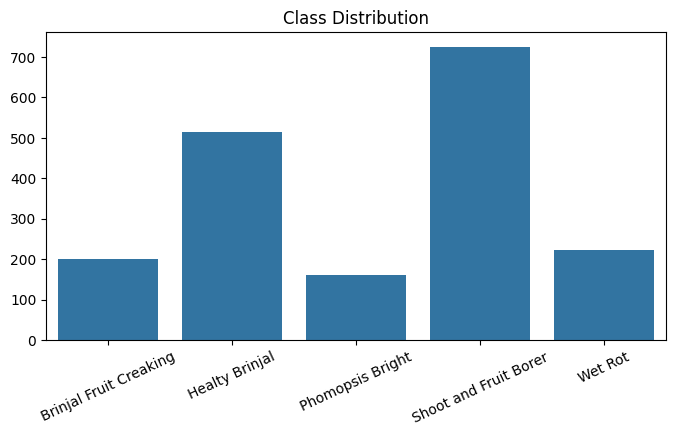

In [8]:
labels = [l for _,l in dataset]

counts = pd.Series(labels).value_counts().sort_index()

plt.figure(figsize=(8,4))
sns.barplot(x=CLASS_NAMES,y=counts.values)
plt.title("Class Distribution")
plt.xticks(rotation=25)
plt.show()

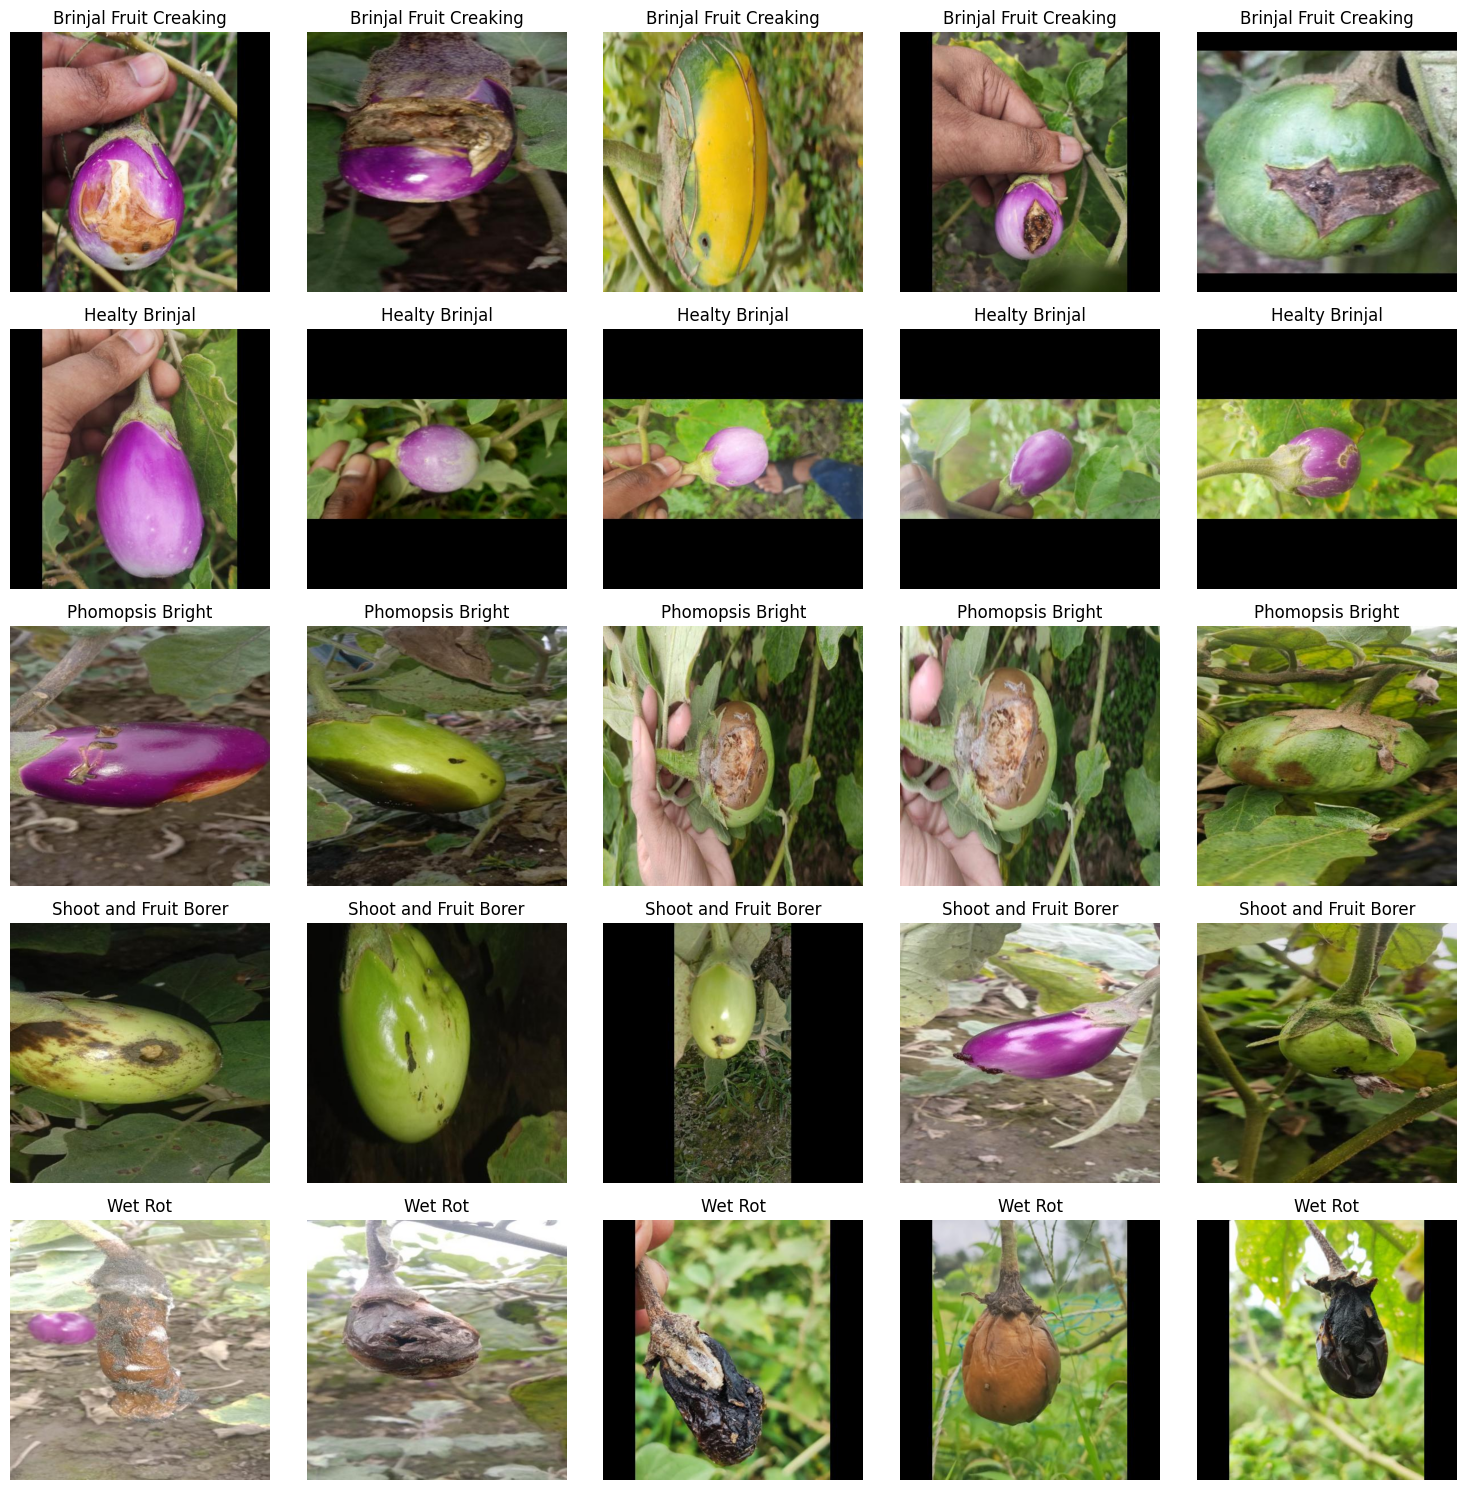

In [9]:
fig, axes = plt.subplots(len(CLASS_NAMES), 5, figsize=(15, 3*len(CLASS_NAMES)))

# group images by class
class_to_indices = {i: [] for i in range(len(CLASS_NAMES))}
for idx, (_, label) in enumerate(dataset):
    class_to_indices[label].append(idx)

# plot 5 images per class
for class_idx, class_name in enumerate(CLASS_NAMES):
    indices = random.sample(class_to_indices[class_idx], 5)  # pick 5 random images for this class
    for i, idx in enumerate(indices):
        img, label = dataset[idx]
        axes[class_idx, i].imshow(img)
        axes[class_idx, i].set_title(class_name)
        axes[class_idx, i].axis("off")

plt.tight_layout()
plt.show()

1276 273 274


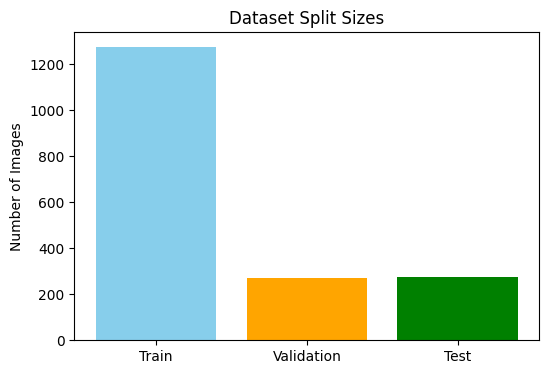

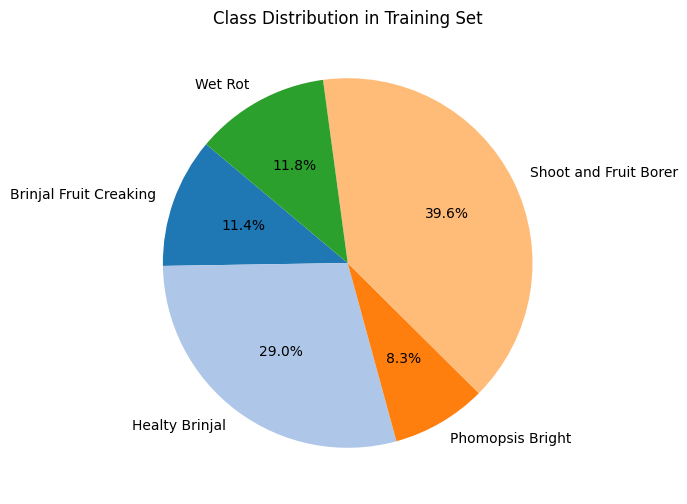

In [10]:
total = len(dataset)

train_size = int(CFG.TRAIN_SPLIT*total)
val_size = int(CFG.VAL_SPLIT*total)
test_size = total-train_size-val_size

train_ds,val_ds,test_ds = random_split(
    dataset,
    [train_size,val_size,test_size],
    generator=torch.Generator().manual_seed(CFG.SEED)
)

print(len(train_ds),len(val_ds),len(test_ds))

# lengths of each split
split_names = ['Train', 'Validation', 'Test']
split_sizes = [len(train_ds), len(val_ds), len(test_ds)]

plt.figure(figsize=(6,4))
plt.bar(split_names, split_sizes, color=['skyblue','orange','green'])
plt.title("Dataset Split Sizes")
plt.ylabel("Number of Images")
plt.show()

# get labels from train_ds
train_labels = [train_ds[i][1] for i in range(len(train_ds))]

# count per class
train_counts = pd.Series(train_labels).value_counts().sort_index()

plt.figure(figsize=(6,6))
plt.pie(
    train_counts.values, 
    labels=CLASS_NAMES, 
    autopct='%1.1f%%', 
    startangle=140,
    colors=plt.cm.tab20.colors
)
plt.title("Class Distribution in Training Set")
plt.show()

⏳ Analyzing image properties (sampling 30 images/class)...


/tmp/ipykernel_24/1549745648.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,2].boxplot([props[props['class']==c]['aspect'].values for c in CLASS_NAMES], labels=short)
/tmp/ipykernel_24/1549745648.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,2].boxplot([props[props['class']==c]['std'].values for c in CLASS_NAMES], labels=short)


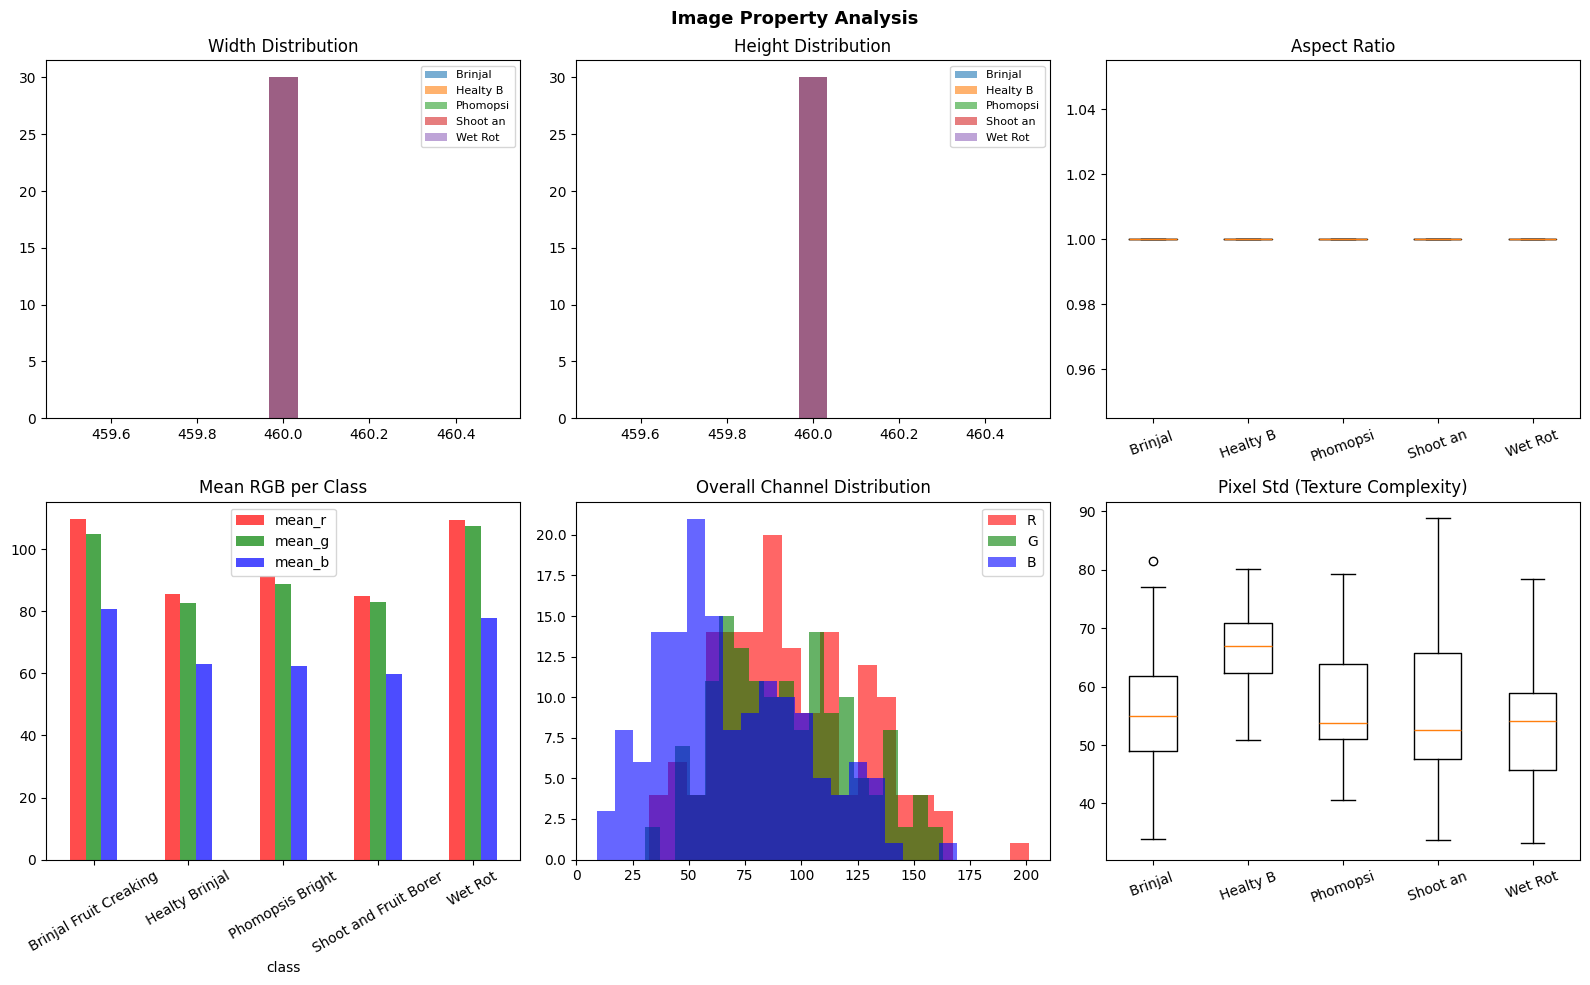

Avg size: 460×460px


In [11]:
print("⏳ Analyzing image properties (sampling 30 images/class)...")

# COLORS for plotting
COLORS = plt.cm.tab10.colors  # 10 distinct colors
short = [c[:8] for c in CLASS_NAMES]  # short names for plotting

records = []

# For each class, sample 30 images
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    # get all indices for this class in dataset
    cls_indices = [i for i, (_, label) in enumerate(dataset) if label == cls_idx]
    sampled_indices = random.sample(cls_indices, min(30, len(cls_indices)))  # sample 30 or less if <30 images

    for idx in sampled_indices:
        img, label = dataset[idx]
        # Convert to numpy array
        arr = np.array(img)
        records.append({
            'class': cls_name,
            'width': arr.shape[1],
            'height': arr.shape[0],
            'aspect': arr.shape[1]/arr.shape[0],
            'mean_r': arr[:,:,0].mean(),
            'mean_g': arr[:,:,1].mean(),
            'mean_b': arr[:,:,2].mean(),
            'std': arr.std()
        })

props = pd.DataFrame(records)

# ─── Plotting ───────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Image Property Analysis', fontsize=13, fontweight='bold')

# Width and height distributions
for i, cls in enumerate(CLASS_NAMES):
    sub = props[props['class']==cls]
    axes[0,0].hist(sub['width'],  alpha=0.6, color=COLORS[i], label=short[i], bins=15)
    axes[0,1].hist(sub['height'], alpha=0.6, color=COLORS[i], label=short[i], bins=15)
axes[0,0].set_title('Width Distribution');  axes[0,0].legend(fontsize=8)
axes[0,1].set_title('Height Distribution'); axes[0,1].legend(fontsize=8)

# Aspect ratio
axes[0,2].boxplot([props[props['class']==c]['aspect'].values for c in CLASS_NAMES], labels=short)
axes[0,2].set_title('Aspect Ratio'); axes[0,2].tick_params(axis='x', rotation=20)

# Mean RGB per class
props.groupby('class')[['mean_r','mean_g','mean_b']].mean().plot(
    kind='bar', ax=axes[1,0], color=['red','green','blue'], alpha=0.7)
axes[1,0].set_title('Mean RGB per Class'); axes[1,0].tick_params(axis='x', rotation=30)

# Overall channel distribution
for i, ch in enumerate(['mean_r','mean_g','mean_b']):
    axes[1,1].hist(props[ch], alpha=0.6, color=['red','green','blue'][i],
                   label=['R','G','B'][i], bins=20)
axes[1,1].set_title('Overall Channel Distribution'); axes[1,1].legend()

# Pixel std (texture)
axes[1,2].boxplot([props[props['class']==c]['std'].values for c in CLASS_NAMES], labels=short)
axes[1,2].set_title('Pixel Std (Texture Complexity)'); axes[1,2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print(f"Avg size: {props['width'].mean():.0f}×{props['height'].mean():.0f}px")

# [W] Data Preprocessing & Augmentation

In [12]:
# ── Transforms ─────────────────────────────────────────────────────

train_transform = transforms.Compose([
    transforms.Resize((CFG.IMG_SIZE,CFG.IMG_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),

    transforms.RandomResizedCrop(
        CFG.IMG_SIZE,
        scale=(0.9,1.0)
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN,IMAGENET_STD)
])

val_transform = transforms.Compose([
    transforms.Resize((CFG.IMG_SIZE,CFG.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN,IMAGENET_STD)
])

In [13]:
# ── Datasets & DataLoaders ─────────────────────────────────────────
train_dataset = datasets.ImageFolder(
    DATA_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    DATA_DIR,
    transform=val_transform
)

test_dataset = datasets.ImageFolder(
    DATA_DIR,
    transform=val_transform
)

In [14]:
indices = list(range(len(train_dataset)))
random.shuffle(indices)
train_idx = indices[:train_size]
val_idx = indices[train_size:train_size+val_size]
test_idx = indices[train_size+val_size:]

#Creating Subset================

train_ds = Subset(train_dataset, train_idx)
val_ds = Subset(val_dataset, val_idx)
test_ds = Subset(test_dataset, test_idx)

In [15]:
# =========================================================
# AUGMENTATION SAMPLE STATISTICS
# =========================================================

num_samples = 100
augmented_pixels = []

for i in range(num_samples):

    img,_ = train_dataset[random.randint(0,len(train_dataset)-1)]

    augmented_pixels.append(img.mean().item())

print("Augmentation Sample Statistics")
print("Mean pixel value:", np.mean(augmented_pixels))
print("Std pixel value:", np.std(augmented_pixels))

Augmentation Sample Statistics
Mean pixel value: -0.6099805296026171
Std pixel value: 0.4815245013296833


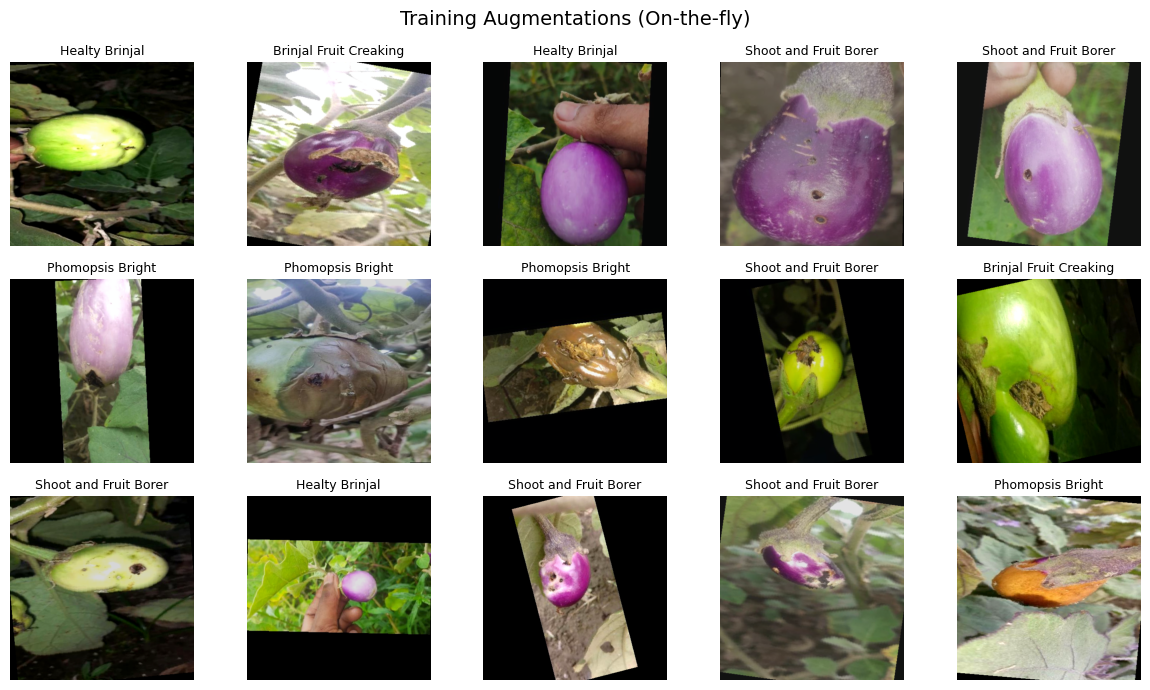

In [16]:
# =========================================================
# AUGMENTATION VISUALIZATION
# =========================================================

def denormalize(img):
    img = img.clone().permute(1,2,0).numpy()
    img = img * IMAGENET_STD + IMAGENET_MEAN
    img = np.clip(img,0,1)
    return img


fig, ax = plt.subplots(3,5, figsize=(12,7))

for i in range(15):

    img,label = train_dataset[random.randint(0,len(train_dataset)-1)]
    
    img = denormalize(img)

    ax[i//5, i%5].imshow(img)
    ax[i//5, i%5].axis("off")
    ax[i//5, i%5].set_title(CLASS_NAMES[label], fontsize=9)  # show class name

plt.suptitle("Training Augmentations (On-the-fly)", fontsize=14)
plt.tight_layout()
plt.show()

# [T] Training Infrastructure

In [17]:
train_loader = DataLoader(
    train_ds,
    batch_size=CFG.BATCH_SIZE,
    shuffle=True,
    num_workers=CFG.NUM_WORKERS
)

val_loader = DataLoader(
    val_ds,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False
)

In [18]:
# =========================================================
# AUGMENTATION STATISTICS
# =========================================================

train_size = len(train_ds)
epochs = CFG.EPOCHS

effective_samples = train_size * epochs

print("Original training images :", train_size)
print("Epochs :", epochs)
print("Effective augmented samples seen by model for training :", effective_samples)

print("\nExplanation:")
print("Each epoch applies random augmentation to every image.")
print("So the model effectively sees different versions of the same image each epoch.")

Original training images : 1276
Epochs : 30
Effective augmented samples seen by model for training : 38280

Explanation:
Each epoch applies random augmentation to every image.
So the model effectively sees different versions of the same image each epoch.


In [19]:
class_counts = counts.values

weights = 1.0 / torch.tensor(class_counts,dtype=torch.float)

class_weights = weights / weights.sum()

class_weights = class_weights.to(DEVICE)

print(class_weights)

tensor([0.2629, 0.1023, 0.3266, 0.0725, 0.2358], device='cuda:0')


In [20]:
def train_epoch(model,loader,optimizer,criterion):

    model.train()

    losses=[]
    preds=[]
    labels=[]

    for x,y in loader:

        x=x.to(DEVICE)
        y=y.to(DEVICE)

        optimizer.zero_grad()

        out=model(x)

        loss=criterion(out,y)

        loss.backward()

        optimizer.step()

        losses.append(loss.item())

        preds.extend(out.argmax(1).cpu().numpy())
        labels.extend(y.cpu().numpy())

    acc=accuracy_score(labels,preds)

    return np.mean(losses),acc

In [21]:
def plot_history(history, name):
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'{name} — Training History', fontsize=12, fontweight='bold')
    ep = range(1, len(history['val_acc'])+1)
    
    # Loss
    a1.plot(ep, history['train_loss'], 'b-o', ms=3, label='Train')
    a1.plot(ep, history['val_loss'],   'r-o', ms=3, label='Val')
    a1.set_title('Loss'); a1.legend(); a1.grid(alpha=.3)
    
    # Accuracy
    a2.plot(ep, history['train_acc'], 'b-o', ms=3, label='Train')
    a2.plot(ep, history['val_acc'],  'r-o', ms=3, label='Val')
    a2.set_title('Accuracy (%)'); a2.legend(); a2.grid(alpha=.3)
    
    plt.tight_layout()
    plt.show()

In [22]:
def train_and_plot(model, train_loader, val_loader, optimizer, criterion, epochs, model_name="Model"):
    """
    Train a PyTorch model and plot training/validation loss & accuracy.

    Args:
        model       : PyTorch model
        train_loader: DataLoader for training set
        val_loader  : DataLoader for validation set
        optimizer   : optimizer (e.g., Adam)
        criterion   : loss function (e.g., CrossEntropyLoss)
        epochs      : number of training epochs
        model_name  : name for plot and print statements
    Returns:
        history: dict containing train/val loss and accuracy per epoch
    """
    
    # Move model to device
    model = model.to(DEVICE)
    
    # Initialize history
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    best_val_acc = 0.0
    best_epoch = 0
    patience_ctr = 0
    EARLY_STOP_PAT = 10
    
    for epoch in range(1, epochs+1):
        # -------- Train --------
        model.train()
        tr_losses, tr_preds, tr_labels = [], [], []
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            
            tr_losses.append(loss.item())
            tr_preds.extend(out.argmax(1).cpu().numpy())
            tr_labels.extend(y.cpu().numpy())
        
        tr_loss = np.mean(tr_losses)
        tr_acc  = accuracy_score(tr_labels, tr_preds)
        
        # -------- Validate --------
        model.eval()
        val_losses, val_preds, val_labels = [], [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                out = model(x)
                loss = criterion(out, y)
                val_losses.append(loss.item())
                val_preds.extend(out.argmax(1).cpu().numpy())
                val_labels.extend(y.cpu().numpy())
        
        val_loss = np.mean(val_losses)
        val_acc  = accuracy_score(val_labels, val_preds)
        
        # Save metrics
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(val_acc)
        
        # Track best val accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch=epoch
            torch.save(model.state_dict(), f"{model_name}_best.pth")
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= EARLY_STOP_PAT:
                print(f"  ⏹️  Early stop at epoch {epoch}")
                break
        
        print(f"{model_name} | Epoch {epoch}/{epochs} | Train Acc {tr_acc:.3f} | Val Acc {val_acc:.3f}")
    
    print(f"\n✅ Best Val Acc: {best_val_acc*100:.2f}% at epoch {best_epoch}")
    
    # -------- Plot history --------
    plot_history(history, name=model_name)
    
    return history

In [23]:
def evaluate(model, loader, criterion):
    model.eval()

    losses, preds, labels, probs = [], [], [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            out = model(x)
            loss = criterion(out, y)

            p = torch.softmax(out, dim=1)

            losses.append(loss.item())
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(y.cpu().numpy())
            probs.extend(p.cpu().numpy())

    acc=accuracy_score(labels,preds)

    return np.mean(losses), acc, np.array(preds), np.array(labels), np.array(probs)

# [O] CNN Model:
## MobileNetV3


In [24]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CNN Model 1: MobileNetV3-Large                                  ║
# ╠══════════════════════════════════════════════════════════════════╣
# ║  Architecture:                                                    ║
# ║  - Inverted residual blocks (like MobileNetV2)                    ║
# ║  - Squeeze-and-Excitation (SE) in later layers                   ║
# ║  - Hard-Swish activation (approximates Swish, avoids exp())      ║
# ║  - NetAdapt search for optimal layer configs                      ║
# ║  - Minimal Params → fastest inference, ideal for deployment       ║
# ╚══════════════════════════════════════════════════════════════════╝

mobilenet = models.mobilenet_v3_large(pretrained=True)

mobilenet.classifier[3] = nn.Linear(
    mobilenet.classifier[3].in_features,
    NUM_CLASSES
)

mobilenet = mobilenet.to(DEVICE)

print("MobileNet Params:",
      sum(p.numel() for p in mobilenet.parameters())/1e6,"M")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 152MB/s]


MobileNet Params: 4.208437 M


In [25]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(
    mobilenet.parameters(),
    lr=CFG.LR
)

MobileNet | Epoch 1/30 | Train Acc 0.679 | Val Acc 0.857
MobileNet | Epoch 2/30 | Train Acc 0.871 | Val Acc 0.872
MobileNet | Epoch 3/30 | Train Acc 0.911 | Val Acc 0.901
MobileNet | Epoch 4/30 | Train Acc 0.933 | Val Acc 0.923
MobileNet | Epoch 5/30 | Train Acc 0.932 | Val Acc 0.912
MobileNet | Epoch 6/30 | Train Acc 0.941 | Val Acc 0.905
MobileNet | Epoch 7/30 | Train Acc 0.958 | Val Acc 0.901
MobileNet | Epoch 8/30 | Train Acc 0.966 | Val Acc 0.912
MobileNet | Epoch 9/30 | Train Acc 0.962 | Val Acc 0.930
MobileNet | Epoch 10/30 | Train Acc 0.972 | Val Acc 0.919
MobileNet | Epoch 11/30 | Train Acc 0.966 | Val Acc 0.938
MobileNet | Epoch 12/30 | Train Acc 0.975 | Val Acc 0.916
MobileNet | Epoch 13/30 | Train Acc 0.966 | Val Acc 0.930
MobileNet | Epoch 14/30 | Train Acc 0.976 | Val Acc 0.927
MobileNet | Epoch 15/30 | Train Acc 0.974 | Val Acc 0.934
MobileNet | Epoch 16/30 | Train Acc 0.971 | Val Acc 0.930
MobileNet | Epoch 17/30 | Train Acc 0.971 | Val Acc 0.875
MobileNet | Epoch 18/30

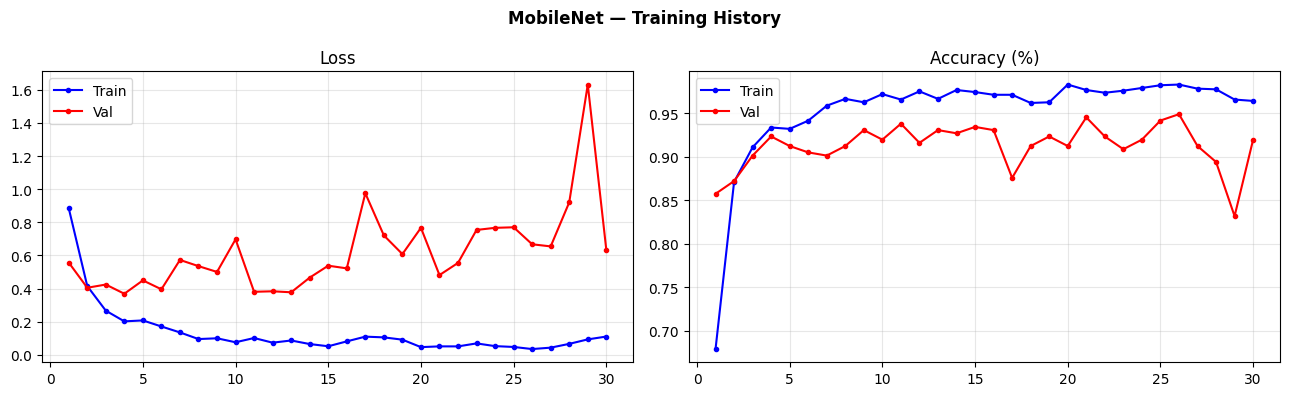

In [26]:
    history_mobilenet = train_and_plot(
    model=mobilenet,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=CFG.EPOCHS,
    model_name="MobileNet"
)

# [ ] Evaluation & Comparison

In [27]:
mobilenet.load_state_dict(torch.load("MobileNet_best.pth"))
mobilenet.to(DEVICE)

_,acc,preds,labels, probs = evaluate(
    mobilenet,
    test_loader,
    criterion
)

print("Test Accuracy:",f"{acc*100:.4f}%")

print(classification_report(
    labels,
    preds,
    target_names=CLASS_NAMES
))

Test Accuracy: 92.7007%
                        precision    recall  f1-score   support

Brinjal Fruit Creaking       0.91      0.86      0.88        35
        Healty Brinjal       0.92      0.96      0.94        81
      Phomopsis Bright       0.83      0.83      0.83        18
 Shoot and Fruit Borer       0.94      0.92      0.93       111
               Wet Rot       0.97      1.00      0.98        29

              accuracy                           0.93       274
             macro avg       0.91      0.91      0.91       274
          weighted avg       0.93      0.93      0.93       274



## Inference Time 

In [28]:
# Inference time
start = time.time()
_ = evaluate(mobilenet, test_loader, criterion)
end = time.time()

inf_time = (end - start) / len(test_loader)

precision_macro = precision_score(labels, preds, average='macro')
recall_macro    = recall_score(labels, preds, average='macro')
f1_macro        = f1_score(labels, preds, average='macro')

precision_w = precision_score(labels, preds, average='weighted')
recall_w    = recall_score(labels, preds, average='weighted')
f1_w        = f1_score(labels, preds, average='weighted')

print("\n=== Evaluation Metrics ===")
print(f"Accuracy       : {acc*100:.2f}%")
print(f"Precision (M)  : {precision_macro:.3f}")
print(f"Recall (M)     : {recall_macro:.3f}")
print(f"F1-score (M)   : {f1_macro:.3f}")
print(f"F1-score (W)   : {f1_w:.3f}")
print(f"Inference time : {inf_time:.4f} sec/batch")


=== Evaluation Metrics ===
Accuracy       : 92.70%
Precision (M)  : 0.914
Recall (M)     : 0.914
F1-score (M)   : 0.914
F1-score (W)   : 0.927
Inference time : 0.1233 sec/batch


## Unified Table

In [29]:
results_df = pd.DataFrame([{
    "Model": "MobileNetV3",
    "Accuracy": acc*100,
    "F1 Macro": f1_macro*100,
    "F1 Weighted": f1_w*100,
    "Precision Macro": precision_macro*100,
    "Recall Macro": recall_macro*100,
    "Inference Time (s/batch)": inf_time
}])
print('\n Unified Table\n')
print(results_df)


 Unified Table

         Model  Accuracy  F1 Macro  F1 Weighted  Precision Macro  \
0  MobileNetV3  92.70073  91.40006    92.667361        91.423648   

   Recall Macro  Inference Time (s/batch)  
0     91.447161                  0.123267  


## Confusion Matrix

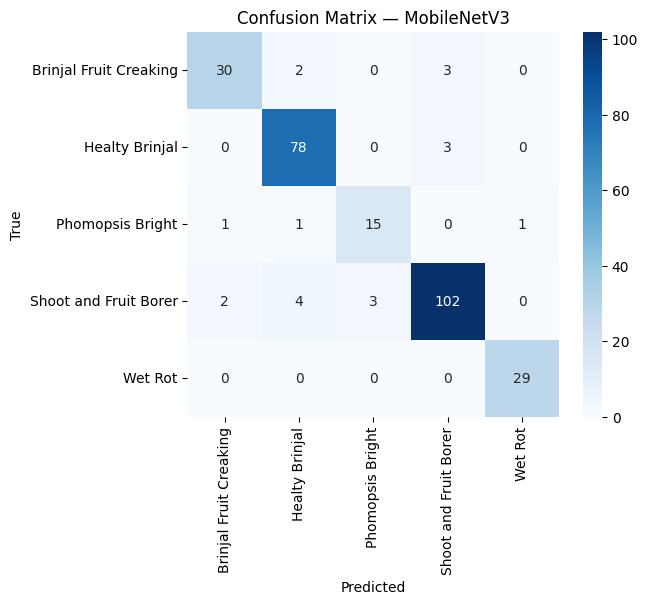

In [30]:
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — MobileNetV3")
plt.show()

## ROC-Curve

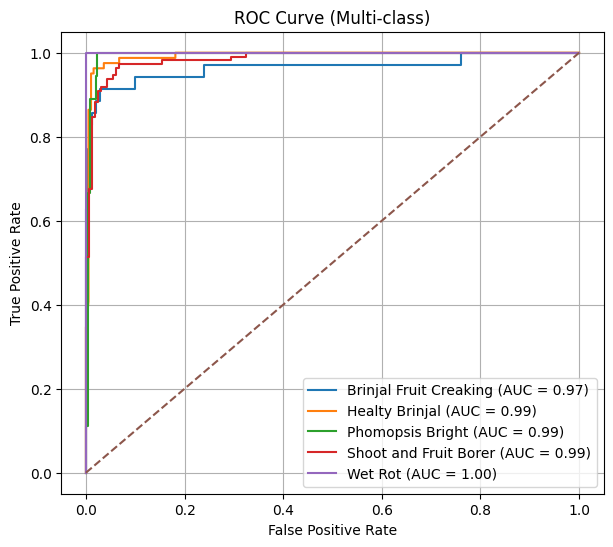

In [31]:
num_classes = len(CLASS_NAMES)

labels_bin = label_binarize(labels, classes=list(range(num_classes)))
probs = np.array(probs)
fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(labels_bin[:, i], probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
plt.figure(figsize=(7,6))

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"{CLASS_NAMES[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1], [0,1], linestyle='--')  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-class)")
plt.legend()
plt.grid()
plt.show()

# [S] Robustness Analysis

In [32]:
def noise_transform(sigma):
    return transforms.Compose([
        transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        transforms.Lambda(lambda x: x + torch.randn_like(x)*sigma)
    ])

def brightness_transform(factor):
    return transforms.Compose([
        transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
        transforms.ColorJitter(brightness=(factor, factor)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ])

def contrast_transform(factor):
    return transforms.Compose([
        transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
        transforms.ColorJitter(contrast=(factor, factor)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ])
def blur_transform(kernel_size):
    return transforms.Compose([
        transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
        transforms.GaussianBlur(kernel_size=kernel_size),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ])

def rotation_transform(angle):
    return transforms.Compose([
        transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
        transforms.Lambda(lambda img: TF.rotate(img, angle)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ])



In [33]:
corruptions = {
    "Clean (Baseline)": val_transform,

    "Gaussian Noise σ=0.05": noise_transform(0.05),
    "Gaussian Noise σ=0.15": noise_transform(0.15),

    "Gaussian Blur k=3": blur_transform(3),
    "Gaussian Blur k=9": blur_transform(9),

    "Overexposure (bright)": brightness_transform(1.8),
    "Low Contrast": contrast_transform(0.4),

    "Rotation 45°": rotation_transform(45),
}
rob_results = {}

print("\n=== Robustness Evaluation ===\n")

for i, (name, tfm) in enumerate(corruptions.items()):
    ds = datasets.ImageFolder(DATA_DIR, transform=tfm)
    subset = Subset(ds, test_idx)

    loader = DataLoader(subset, batch_size=CFG.BATCH_SIZE, shuffle=False)

    _, acc_c, preds_c, labels_c, _ = evaluate(mobilenet, loader, criterion)

    f1_c = f1_score(labels_c, preds_c, average='macro')

    rob_results[name] = (acc_c*100, f1_c*100)

    # Pretty formatting
    if i == 0:
        print(f"✅ {name:<30} Acc={acc_c*100:.2f}%  F1={f1_c*100:.2f}%")
    else:
        print(f"   {name:<30} Acc={acc_c*100:.2f}%  F1={f1_c*100:.2f}%")


=== Robustness Evaluation ===

✅ Clean (Baseline)               Acc=92.70%  F1=91.40%
   Gaussian Noise σ=0.05          Acc=93.80%  F1=92.65%
   Gaussian Noise σ=0.15          Acc=93.07%  F1=92.11%
   Gaussian Blur k=3              Acc=93.07%  F1=91.70%
   Gaussian Blur k=9              Acc=92.70%  F1=90.91%
   Overexposure (bright)          Acc=89.78%  F1=86.95%
   Low Contrast                   Acc=91.24%  F1=88.19%
   Rotation 45°                   Acc=91.97%  F1=91.62%


## Plot Performance

In [34]:
data = []
for name, (acc, f1) in rob_results.items():
    data.append([name, acc, f1])

df = pd.DataFrame(data, columns=["Condition", "Accuracy", "F1"])

baseline = df.iloc[0]["Accuracy"]
df["Degradation"] = baseline - df["Accuracy"]

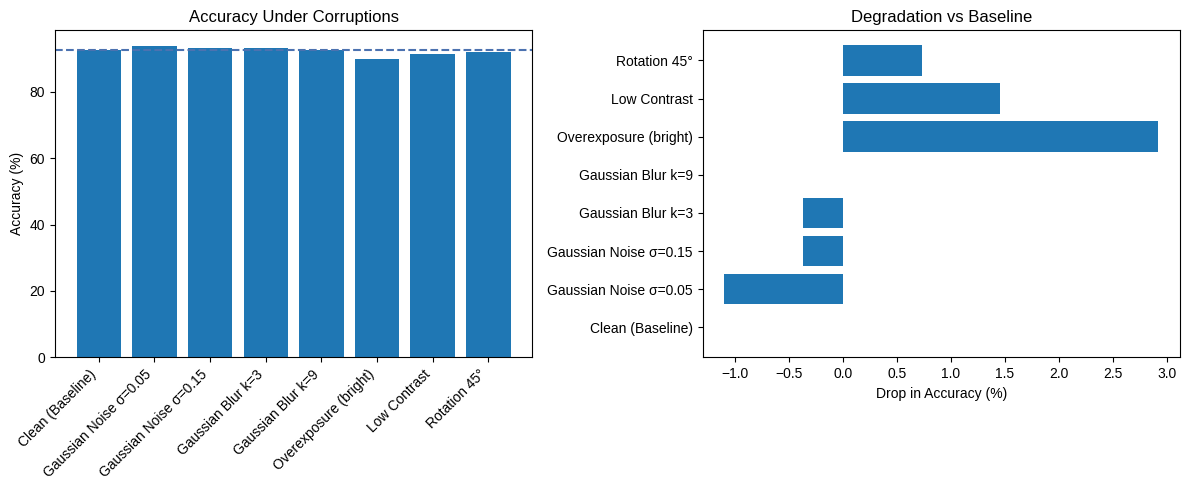

In [35]:
plt.figure(figsize=(12,5))

# --- Left: Accuracy ---
plt.subplot(1,2,1)
plt.bar(df["Condition"], df["Accuracy"])
plt.axhline(y=baseline, linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.title("Accuracy Under Corruptions")
plt.ylabel("Accuracy (%)")

# --- Right: Degradation ---
plt.subplot(1,2,2)
plt.barh(df["Condition"], df["Degradation"])
plt.title("Degradation vs Baseline")
plt.xlabel("Drop in Accuracy (%)")
plt.style.use('seaborn-v0_8')
plt.tight_layout()
plt.show()

## GradCAM++

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
/tmp/ipykernel_24/148849002.py:137: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_24/148849002.py:138: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Liberation Sans.
  plt.savefig("gradcam_mobilenet.png", dpi=300, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


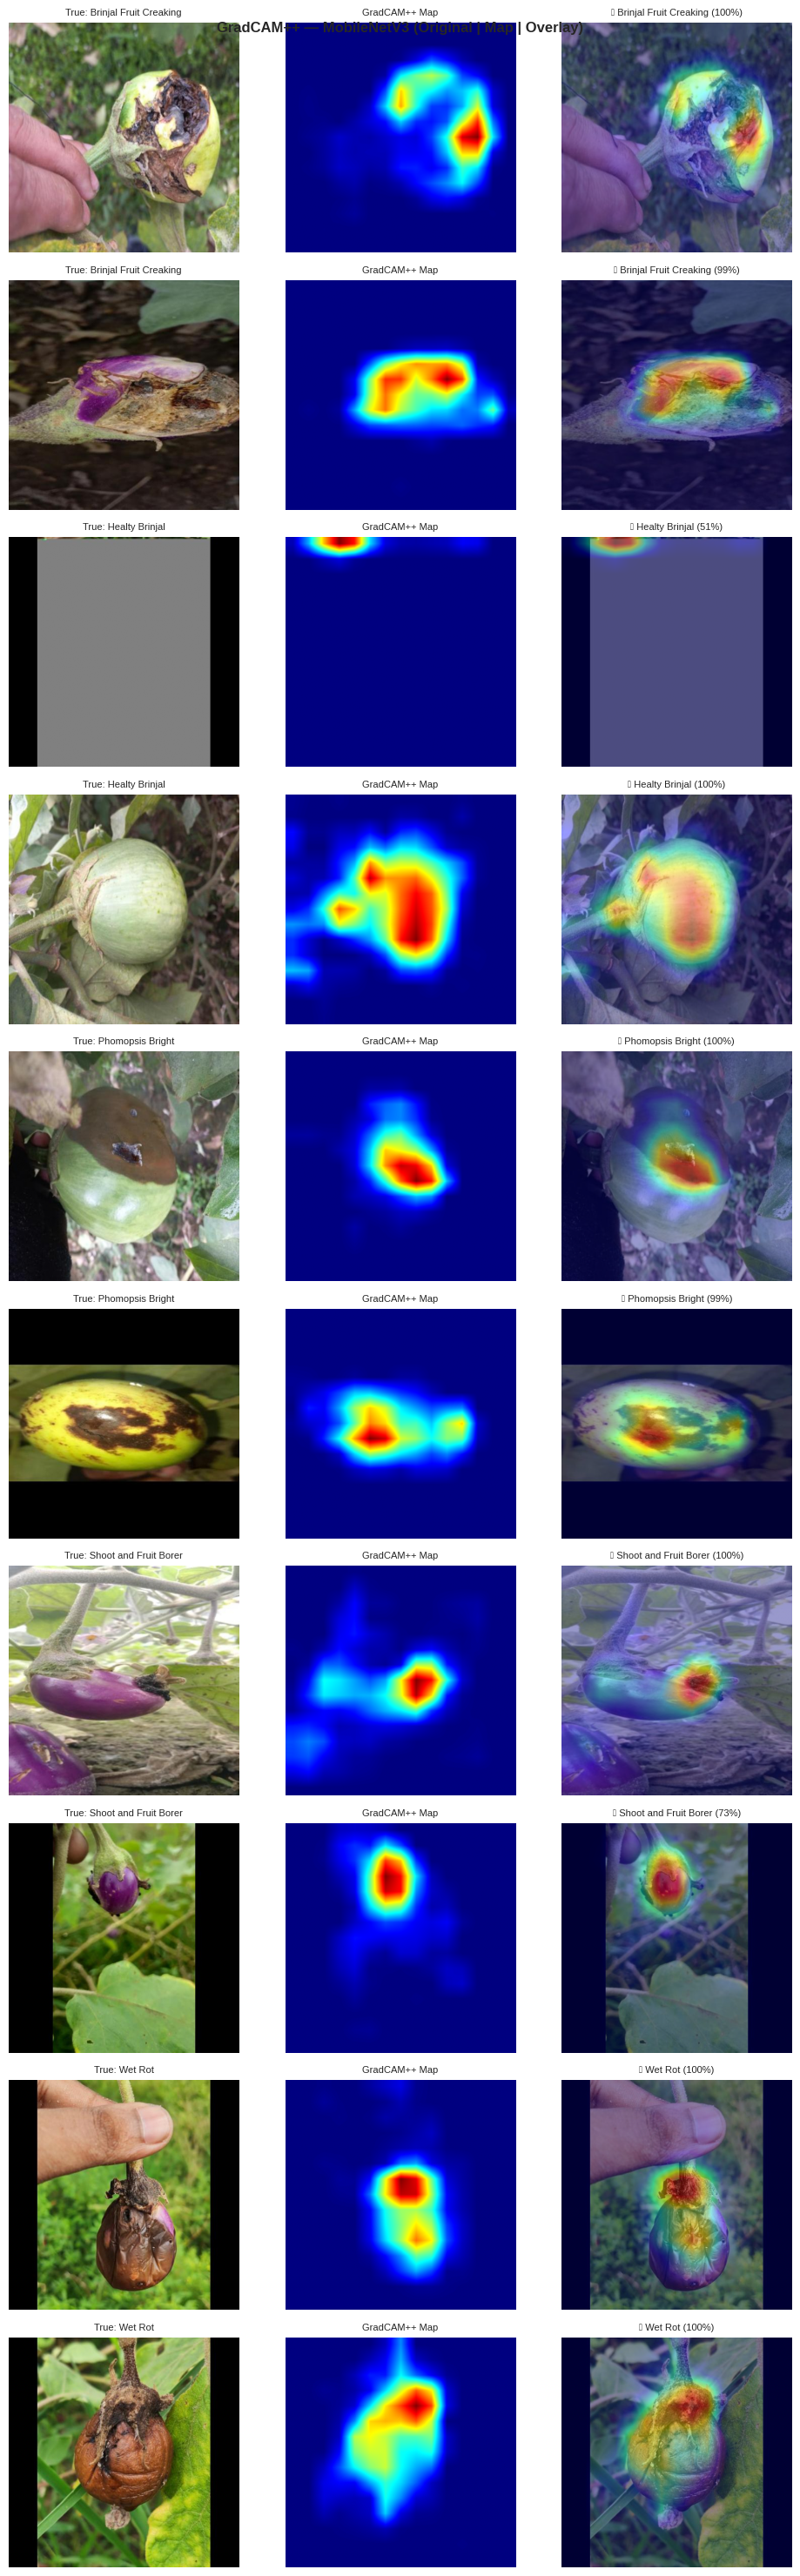

In [36]:
# ── GradCAM++ Explainability ───────────────────────────────────────
"""
GradCAM++ uses second-order gradients for better localization.
heatmap = ReLU( Σ_k α_k^c · A_k )
Shows which regions influence model prediction.
"""
# -------------------------------
# Target layer selector
# -------------------------------
def get_target_layer(model):
    # MobileNetV3 (your case)
    return model.features[-1]


# -------------------------------
# GradCAM++ class (no external lib)
# -------------------------------
class GradCAMPlusPlus:
    def __init__(self, model, target_layer):
        self.model = model.eval()
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        target_layer.register_forward_hook(self.forward_hook)
        target_layer.register_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output.detach()

    def backward_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, x, class_idx=None):
        self.model.zero_grad()

        out = self.model(x)

        if class_idx is None:
            class_idx = out.argmax(dim=1).item()

        score = out[:, class_idx]
        score.backward(retain_graph=True)

        grads = self.gradients[0]      # [C,H,W]
        acts  = self.activations[0]    # [C,H,W]

        # GradCAM++ weights
        grad_2 = grads ** 2
        grad_3 = grads ** 3

        eps = 1e-8
        alpha = grad_2 / (2*grad_2 + (acts * grad_3).sum((1,2), keepdim=True) + eps)

        weights = (alpha * F.relu(grads)).sum((1,2))

        cam = (weights.view(-1,1,1) * acts).sum(0)
        cam = F.relu(cam)

        cam -= cam.min()
        cam /= (cam.max() + 1e-8)

        return cam.cpu().numpy(), class_idx


# -------------------------------
# Image loader
# -------------------------------
def raw_and_tensor(img_path):
    img = Image.open(img_path).convert('RGB').resize((CFG.IMG_SIZE, CFG.IMG_SIZE))
    raw = np.array(img) / 255.0
    tensor = val_transform(img).unsqueeze(0).to(DEVICE)
    return raw, tensor


# -------------------------------
# Overlay function
# -------------------------------
def overlay_cam(raw, cam):
    cam = cv2.resize(cam, (raw.shape[1], raw.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = heatmap[..., ::-1] / 255.0  # BGR → RGB

    overlay = heatmap * 0.4 + raw * 0.6
    return heatmap, np.clip(overlay, 0, 1)


# -------------------------------
# Run GradCAM++
# -------------------------------
try:
    target_layer = get_target_layer(mobilenet)
    gradcam = GradCAMPlusPlus(mobilenet, target_layer)

    samples_per_class = 2
    rows = len(CLASS_NAMES) * samples_per_class

    fig, axes = plt.subplots(rows, 3, figsize=(10, rows*3))
    fig.suptitle("GradCAM++ — MobileNetV3 (Original | Map | Overlay)", fontsize=12, fontweight='bold')

    row = 0

    for ci, cls in enumerate(CLASS_NAMES):
        class_path = os.path.join(DATA_DIR, cls)
        imgs = os.listdir(class_path)[:samples_per_class]

        for img_name in imgs:
            path = os.path.join(class_path, img_name)

            raw, tensor = raw_and_tensor(path)

            with torch.no_grad():
                out = mobilenet(tensor)
                pred = out.argmax(1).item()
                conf = F.softmax(out,1)[0,pred].item()

            cam, _ = gradcam.generate(tensor, class_idx=pred)
            heatmap, overlay = overlay_cam(raw, cam)

            tick = "✅" if pred == ci else "❌"

            axes[row,0].imshow(raw)
            axes[row,0].set_title(f"True: {CLASS_NAMES[ci]}", fontsize=8)

            axes[row,1].imshow(heatmap)
            axes[row,1].set_title("GradCAM++ Map", fontsize=8)

            axes[row,2].imshow(overlay)
            axes[row,2].set_title(f"{tick} {CLASS_NAMES[pred]} ({conf:.0%})", fontsize=8)

            for ax in axes[row]:
                ax.axis("off")

            row += 1

    plt.tight_layout()
    plt.savefig("gradcam_mobilenet.png", dpi=300, bbox_inches='tight')
    plt.show()

except Exception as e:
    print("GradCAM failed:", e)

# Error Analysis

## Top-K misclassified samples

In [37]:
test_ds_no_aug = datasets.ImageFolder(DATA_DIR, transform=val_transform)
test_subset = Subset(test_ds_no_aug, test_idx)

errors = []

mobilenet.eval()
with torch.no_grad():
    for i in range(len(test_subset)):
        img, label = test_subset[i]

        out = mobilenet(img.unsqueeze(0).to(DEVICE))
        prob = torch.softmax(out, dim=1)

        pred = out.argmax(1).item()
        conf = prob[0, pred].item()

        if pred != label:
            errors.append((conf, img, label, pred))

# sort by confidence
errors = sorted(errors, key=lambda x: -x[0])

## Visualize top 9 errors

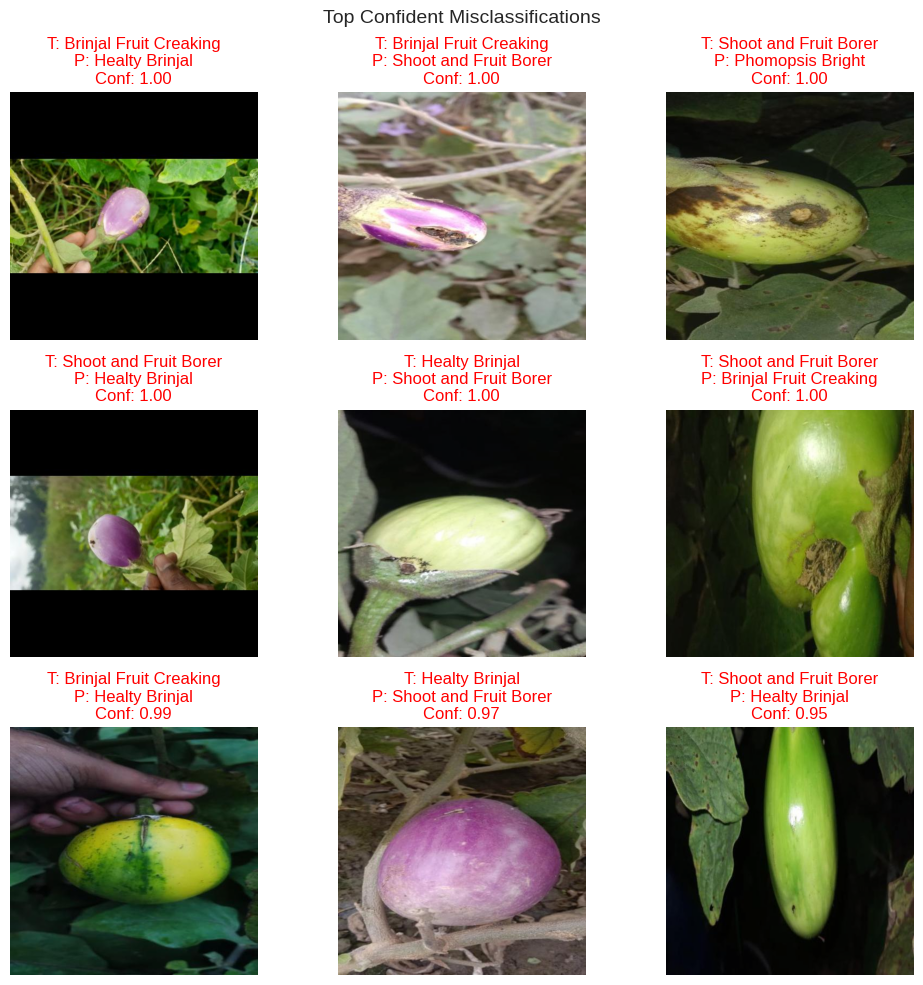

In [38]:
def show_errors(errors, class_names, num_images=9):
    plt.figure(figsize=(10,10))

    for i in range(min(num_images, len(errors))):
        conf, img, true, pred = errors[i]

        plt.subplot(3,3,i+1)
        plt.imshow(denormalize(img))
        plt.axis("off")

        plt.title(
            f"T: {class_names[true]}\nP: {class_names[pred]}\nConf: {conf:.2f}",
            color='red'
        )

    plt.suptitle("Top Confident Misclassifications", fontsize=14)
    plt.tight_layout()
    plt.show()
show_errors(errors, CLASS_NAMES, num_images=9)